# Step 2 — Chunking: Build the RAG Document Database

This notebook assembles all text chunks that will go into the FAISS retrieval index.
It outputs a single `chunks/chunks.csv` file consumed by the next notebook (`rag_step3_index.ipynb`).

**Sources combined here:**
- IHC training examples (loaded from HuggingFace, `post` column)
- ISHate training examples (loaded from HuggingFace, `text` column)
- Vicomtech training examples (local `data/hate-speech-dataset/sampled_train/`, text files)
- External documents: deferred (see section 5)

**Output CSV schema:**
```
chunk_id | text
---------|-------------------------------
0        | [hate] you are all subhuman
1        | [not hate] I love this city
```

The label is baked into the `text` field so retrieved chunks can be used directly in few-shot prompts at inference time.

## 1. Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from transformers import AutoTokenizer

## 2. Load IHC Training Data

Dataset: `tasksource/implicit-hate-stg1`  
Text column: `post`  
Label column: `class` → `not_hate` maps to `not_hate`, everything else maps to `hate`

Only the **training split** is used (90/10 split with seed=42, same as baseline_step1).  
The test split is reserved for inference queries only.  
Labels are kept as a local field for deduplication analysis — not written to the output CSV.

In [2]:
# Full dataset from the IHC, lines are an entry, columns are a feature like post (the text), class (hate/non-hate), ...
ihc_ds = load_dataset("tasksource/implicit-hate-stg1", split="train")
print("Length of the full dataset : ", len(ihc_ds))
# Reproduce the same 90/10 split as baseline_step1 (seed=42) to ensure
ihc_train = ihc_ds.train_test_split(test_size=0.10, seed=42)["train"]
print("Length of the training dataset : ", len(ihc_train))

# Creating the dataset to be chunked, converting the same time implicit/explicite hate into hate because our models will focus on binary classification
ihc_chunks = []
for row in ihc_train:
    label = "not_hate" if row["class"] == "not_hate" else "hate"
    ihc_chunks.append({"source": "ihc_train", "text": row["post"], "label": label})

print(f"IHC training examples: {len(ihc_chunks)}")
print("Examples of the data we have")
for i in range(5):
    print(ihc_chunks[i+5])

README.md:   0%|          | 0.00/792 [00:00<?, ?B/s]

implicit_hate_v1_stg1_posts.tsv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/21480 [00:00<?, ? examples/s]

Length of the full dataset :  21480
Length of the training dataset :  19332


IHC training examples: 19332
Examples of the data we have
{'source': 'ihc_train', 'text': '. help biafrans get freedom and independence . please save biafrans from murderous nigeria terrorists', 'label': 'hate'}
{'source': 'ihc_train', 'text': 'you should dead  racist  motherfuckersthis is ku klux klan', 'label': 'hate'}
{'source': 'ihc_train', 'text': "we're all vertebrates too . except for cucks .", 'label': 'hate'}
{'source': 'ihc_train', 'text': 'white people are not alowed to have opinions if we do we are so bad', 'label': 'not_hate'}
{'source': 'ihc_train', 'text': "how the dynasty turned large chunks of lutyens ' delhi into private property", 'label': 'not_hate'}


## 3. Load ISHate Training Data

Dataset: `BenjaminOcampo/ISHate`  
Text column: `text`  
Label column: `hateful_layer` → `Non-HS` maps to `not_hate`, everything else maps to `hate`

Uses the pre-made train split directly — no manual split needed.

In [3]:
# Same way of loading the data but with different tools
# Load directly only the training data via ishate_train.parquet.gzip
ishate_path = hf_hub_download(repo_id="BenjaminOcampo/ISHate", filename="ishate_train.parquet.gzip", repo_type="dataset")
ishate_df = pd.read_parquet(ishate_path)
print("Length of the training dataset : ", len(ishate_df))

ishate_chunks = []
for _, row in ishate_df.iterrows():
    label = "not_hate" if row["hateful_layer"] == "Non-HS" else "hate"
    ishate_chunks.append({"source": "ishate_train", "text": row["text"], "label": label})

print(f"ISHate training examples: {len(ishate_chunks)}")
print("Examples of the data we have")
for i in range(5):
    print(ishate_chunks[i+5])

ishate_train.parquet.gzip:   0%|          | 0.00/3.45M [00:00<?, ?B/s]

Length of the training dataset :  55023


ISHate training examples: 55023
Examples of the data we have
{'source': 'ishate_train', 'text': "fuk that I burned a qu'ran and pissed on it...", 'label': 'hate'}
{'source': 'ishate_train', 'text': 'You left me in the dark for some bitch that had a kid while you were in the pin but yet you still chose that dry cunt over your son how sad.', 'label': 'not_hate'}
{'source': 'ishate_train', 'text': 'An Illegal Alien took his own life because he decide he would break into the U.S Steal IDs and SSN to Work Illegally Robbing the U.S instead of sending for his family he killed himself Really didnt care about his Family huh ? #SendthemBack #Immigration', 'label': 'hate'}
{'source': 'ishate_train', 'text': '@MailOnline Bloody Germany who needs Germany we dont want their Visa plans were are fed up of being over ran by migrants no Uk Jobs threaten', 'label': 'hate'}
{'source': 'ishate_train', 'text': 'Immigrants are not welcome here, and should not mix with us.', 'label': 'hate'}


## 3.5 Load Vicomtech Training Data

Dataset: `Vicomtech/hate-speech-dataset` (de Gibert et al., 2018) — sentences from Stormfront white-nationalist forum posts stored locally at `data/hate-speech-dataset/`.  
Text: individual `.txt` files in `sampled_train/`.  
Labels: from `annotations_metadata.csv` → `hate` maps to `hate`, `noHate` maps to `not_hate`; `idk/skip` and `relation` labels are discarded.  
Uses the pre-made `sampled_train` split directly.

In [4]:
DATA_DIR = "../data/hate-speech-dataset"
_metadata = pd.read_csv(f"{DATA_DIR}/annotations_metadata.csv").set_index("file_id")

vicomtech_chunks = []
for fname in sorted(os.listdir(f"{DATA_DIR}/sampled_train")):
    if not fname.endswith(".txt"):
        continue
    file_id = fname[:-4]
    if file_id not in _metadata.index:
        continue
    label_str = _metadata.loc[file_id, "label"]
    if label_str not in ("hate", "noHate"):
        continue
    with open(f"{DATA_DIR}/sampled_train/{fname}", encoding="utf-8") as f:
        text = f.read().strip()
    label = "hate" if label_str == "hate" else "not_hate"
    vicomtech_chunks.append({"source": "vicomtech_train", "text": text, "label": label})

print(f"Vicomtech training examples: {len(vicomtech_chunks)}")
for i in range(5):
    print(vicomtech_chunks[i])

Vicomtech training examples: 1914
{'source': 'vicomtech_train', 'text': 'In order to help increase the booklets downloads , it would be great if all Stormfronters who had YouTube accounts , could display the following text in the description boxes of their uploaded YouTube videos .', 'label': 'not_hate'}
{'source': 'vicomtech_train', 'text': 'Click below for a FREE download of a colorfully illustrated 132 page e-book on the Zionist-engineered INTENTIONAL destruction of Western civilization .', 'label': 'hate'}
{'source': 'vicomtech_train', 'text': 'Click below for a FREE download of a colorfully illustrated 132 page e-book on the Zionist-engineered INTENTIONAL destruction of Western civilization .', 'label': 'hate'}
{'source': 'vicomtech_train', 'text': 'Booklet updated on Dec. 9th , 2013 .', 'label': 'not_hate'}
{'source': 'vicomtech_train', 'text': "Thank you in advance. : ) Download the youtube `` description box '' info text file below @ http://www.mediafire.com/download/gxv2b33v37

## 4. Deduplication

Normalization: lowercase + strip whitespace.

### 4a — Analysis
Check for duplicate entries within each dataset and across all three datasets.

In [5]:
tmp_ihc = pd.DataFrame(ihc_chunks)
tmp_ishate = pd.DataFrame(ishate_chunks)
tmp_vicomtech = pd.DataFrame(vicomtech_chunks)

tmp_ihc["norm"] = tmp_ihc["text"].str.lower().str.strip()
tmp_ishate["norm"] = tmp_ishate["text"].str.lower().str.strip()
tmp_vicomtech["norm"] = tmp_vicomtech["text"].str.lower().str.strip()

# Find duplicates within IHC
ihc_dupe_mask = tmp_ihc.duplicated(subset="norm", keep=False)
ihc_dupes = tmp_ihc.duplicated(subset="norm").sum()
print(f"IHC internal duplicates: {ihc_dupes}")
if ihc_dupes:
    sample_norm = tmp_ihc[ihc_dupe_mask]["norm"].iloc[0]
    print(tmp_ihc[tmp_ihc["norm"] == sample_norm][["text"]].to_string(index=False))

# Find duplicates within ISHate
ishate_dupe_mask = tmp_ishate.duplicated(subset="norm", keep=False)
ishate_dupes = tmp_ishate.duplicated(subset="norm").sum()
print(f"\nISHate internal duplicates: {ishate_dupes}")
if ishate_dupes:
    sample_norm = tmp_ishate[ishate_dupe_mask]["norm"].iloc[0]
    print(tmp_ishate[tmp_ishate["norm"] == sample_norm][["text"]].to_string(index=False))

# Find duplicates within Vicomtech
vicomtech_dupe_mask = tmp_vicomtech.duplicated(subset="norm", keep=False)
vicomtech_dupes = tmp_vicomtech.duplicated(subset="norm").sum()
print(f"\nVicomtech internal duplicates: {vicomtech_dupes}")
if vicomtech_dupes:
    sample_norm = tmp_vicomtech[vicomtech_dupe_mask]["norm"].iloc[0]
    print(tmp_vicomtech[tmp_vicomtech["norm"] == sample_norm][["text"]].to_string(index=False))

# Cross-dataset overlaps
overlap_ihc_ishate = set(tmp_ihc["norm"]) & set(tmp_ishate["norm"])
overlap_ihc_vicomtech = set(tmp_ihc["norm"]) & set(tmp_vicomtech["norm"])
overlap_ishate_vicomtech = set(tmp_ishate["norm"]) & set(tmp_vicomtech["norm"])
print(f"\nCross-dataset overlaps — IHC ∩ ISHate: {len(overlap_ihc_ishate)}")
print(f"Cross-dataset overlaps — IHC ∩ Vicomtech: {len(overlap_ihc_vicomtech)}")
print(f"Cross-dataset overlaps — ISHate ∩ Vicomtech: {len(overlap_ishate_vicomtech)}")

IHC internal duplicates: 4
                                                        text
im black and all white people have inferior everything to me
im black and all white people have inferior everything to me

ISHate internal duplicates: 1468
                       text
 women cry over everything 
  women cry over everything

Vicomtech internal duplicates: 6
                                                                                                                                                   text
Click below for a FREE download of a colorfully illustrated 132 page e-book on the Zionist-engineered INTENTIONAL destruction of Western civilization .
Click below for a FREE download of a colorfully illustrated 132 page e-book on the Zionist-engineered INTENTIONAL destruction of Western civilization .



Cross-dataset overlaps — IHC ∩ ISHate: 392
Cross-dataset overlaps — IHC ∩ Vicomtech: 4
Cross-dataset overlaps — ISHate ∩ Vicomtech: 1354


### 4b — Deduplication Solving

Drop duplicates and update `ihc_chunks` / `ishate_chunks` / `vicomtech_chunks`.  
Strategy:
- Within each dataset: keep first occurrence.
- Cross-dataset priority: IHC > ISHate > Vicomtech — keep higher-priority entry, drop duplicate from lower-priority dataset.

In [6]:
previous_ihc_lenght = len(ihc_chunks)
previous_ishate_lenght = len(ishate_chunks)
previous_vicomtech_lenght = len(vicomtech_chunks)

# Within-dataset dedup (keep first occurrence)
tmp_ihc_dedup = tmp_ihc.drop_duplicates(subset="norm", keep="first")
tmp_ishate_dedup = tmp_ishate.drop_duplicates(subset="norm", keep="first")
tmp_vicomtech_dedup = tmp_vicomtech.drop_duplicates(subset="norm", keep="first")

# Cross-dataset: priority IHC > ISHate > Vicomtech
ihc_norms = set(tmp_ihc_dedup["norm"])
tmp_ishate_dedup = tmp_ishate_dedup[~tmp_ishate_dedup["norm"].isin(ihc_norms)]
ihc_ishate_norms = ihc_norms | set(tmp_ishate_dedup["norm"])
tmp_vicomtech_dedup = tmp_vicomtech_dedup[~tmp_vicomtech_dedup["norm"].isin(ihc_ishate_norms)]

# Rebuild chunk lists
ihc_chunks = tmp_ihc_dedup.drop(columns="norm").to_dict("records")
ishate_chunks = tmp_ishate_dedup.drop(columns="norm").to_dict("records")
vicomtech_chunks = tmp_vicomtech_dedup.drop(columns="norm").to_dict("records")

print(f"IHC:        {previous_ihc_lenght:,} → {len(ihc_chunks):,}  (removed {previous_ihc_lenght - len(ihc_chunks)})")
print(f"ISHate:     {previous_ishate_lenght:,} → {len(ishate_chunks):,}  (removed {previous_ishate_lenght - len(ishate_chunks)})")
print(f"Vicomtech:  {previous_vicomtech_lenght:,} → {len(vicomtech_chunks):,}  (removed {previous_vicomtech_lenght - len(vicomtech_chunks)})")
print(f"Total after dedup: {len(ihc_chunks) + len(ishate_chunks) + len(vicomtech_chunks):,}")

IHC:        19,332 → 19,328  (removed 4)
ISHate:     55,023 → 53,163  (removed 1860)
Vicomtech:  1,914 → 552  (removed 1362)
Total after dedup: 73,043


## 5. External Documents

**Work in progress** — External document ingestion (lexicons, typology definitions from `documents/`) will be added in a future iteration. For now only IHC and ISHate training examples are indexed.

## 6. Combine All Sources

In [7]:
all_chunks = ihc_chunks + ishate_chunks + vicomtech_chunks

df = pd.DataFrame(all_chunks)
# insert the labels at the beggining of the text as [hate] or [not hate]
df["text"] = df.apply(lambda r: f"[{r['label'].replace('_', ' ')}] {r['text']}", axis=1)
# keep only the text columns to be chuncked
df = df[["text"]]
df.insert(0, "chunk_id", range(len(df)))

print(f"Total chunks: {df.shape[0]:,}")
df.head()

Total chunks: 73,043


,chunk_id,text
0,0,[not hate] we need everyone to keep winning . ...
1,1,[not hate] : the hatred spewed by robert spenc...
2,2,[not hate] are antifa boomers ?
3,3,[not hate] #trucons aren't capable of anything...
4,4,[not hate] wow you really caught that . so ha...


## 7. Token Length Analysis

The final input to the encoder at inference time will be:
`[CLS] tweet [SEP] chunk1 [SEP] chunk2 [SEP]`

With up to 3 retrieved chunks and a tweet of ~50 tokens:
`50 + 3 × chunk_length + 5 special tokens ≤ 512`

> **Note:** This budget can be revised if the number of retrieved chunks (`k`) or the typical query length changes.

### 7a — Analysis

tokenizer_config.json:   0%|          | 0.00/151 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

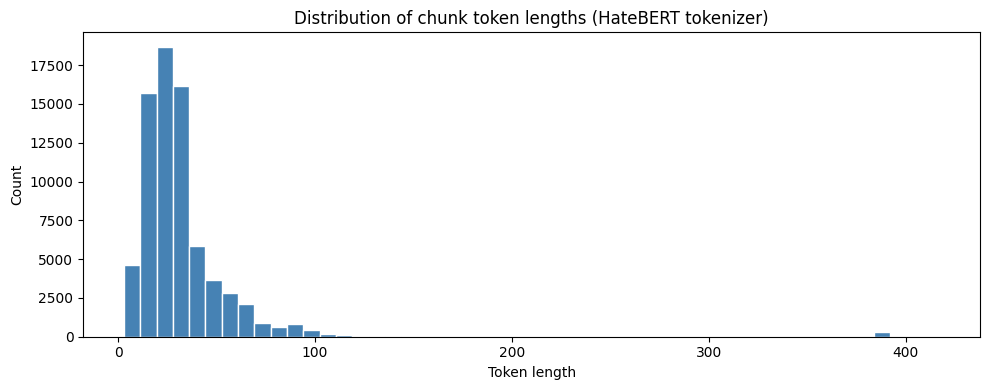

Mean:                32.0
Median:              26.0
95th percentile:     69.0
Max:                 417
Chunks > 50 tokens:  9248


In [8]:
tokenizer = AutoTokenizer.from_pretrained("GroNLP/hateBERT")

token_lengths = [len(tokenizer.encode(t, add_special_tokens=False)) for t in df["text"]]
df["token_length"] = token_lengths

plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=50, color="steelblue", edgecolor="white")
plt.xlabel("Token length")
plt.ylabel("Count")
plt.title("Distribution of chunk token lengths (HateBERT tokenizer)")
plt.tight_layout()
plt.show()

print(f"Mean:                {np.mean(token_lengths):.1f}")
print(f"Median:              {np.median(token_lengths):.1f}")
print(f"95th percentile:     {np.percentile(token_lengths, 95):.1f}")
print(f"Max:                 {max(token_lengths)}")
print(f"Chunks > 50 tokens:  {sum(l > 50 for l in token_lengths)}")

### 7b — Filtering

Remove entries with strictly more than 50 tokens. `chunk_id` is reassigned to stay contiguous.

In [9]:
MAX_TOKENS = 50

before = len(df)
df = df[df["token_length"] <= MAX_TOKENS].drop(columns="token_length").reset_index(drop=True)
df["chunk_id"] = range(len(df))

print(f"Chunks before filtering: {before:,}")
print(f"Chunks after filtering:  {len(df):,}  (removed {before - len(df)})")
df.head()

Chunks before filtering: 73,043
Chunks after filtering:  63,795  (removed 9248)


,chunk_id,text
0,0,[not hate] we need everyone to keep winning . ...
1,1,[not hate] : the hatred spewed by robert spenc...
2,2,[not hate] are antifa boomers ?
3,3,[not hate] #trucons aren't capable of anything...
4,4,[not hate] wow you really caught that . so ha...


## 8. Save

Output: `chunks/chunks.csv` — the only input needed by `rag_step3_index.ipynb`.  
Schema: `chunk_id | text`

In [10]:
os.makedirs("chunks", exist_ok=True)
df.to_csv("chunks/chunks.csv", index=False)
print(f"Saved {len(df):,} chunks to chunks/chunks.csv")

Saved 63,795 chunks to chunks/chunks.csv
